In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ২০২৩-২০২৪ সালের মাসিক ই-সেবা ডেটা (নাটোর জেলা)
np.random.seed(42)

maas = ['জান','ফেব','মার্চ','এপ্রি','মে','জুন',
        'জুলা','আগস্ট','সেপ্ট','অক্টো','নভে','ডিসে']

# প্রতিটি উপজেলার বার্ষিক ট্রেন্ড (ধীরে বাড়ছে)
base = {'নলডাঙ্গা':300,'সিংড়া':750,'গুরুদাসপুর':480,
        'বড়াইগ্রাম':360,'লালপুর':430,'বাগাতিপাড়া':230}

data = {}
for upazila, b in base.items():
    trend = np.linspace(b*0.85, b*1.15, 12)
    noise = np.random.normal(0, b*0.05, 12)
    data[upazila] = (trend + noise).round(0).astype(int)

df = pd.DataFrame(data, index=maas)
print("=== মাসিক আবেদন ডেটা ===")
print(df)
print(f"\nজেলা মোট (বার্ষিক): {df.values.sum():,} টি আবেদন")

=== মাসিক আবেদন ডেটা ===
       নলডাঙ্গা  সিংড়া  গুরুদাসপুর  বড়াইগ্রাম  লালপুর  বাগাতিপাড়া
জান         262     647         395         310     373          190
ফেব         261     586         424         281     339          200
মার্চ       281     614         407         302     396          195
এপ্রি       302     678         456         339     392          201
মে          284     681         446         359     398          230
জুন         292     752         466         358     437          242
জুলা        328     726         472         363     458          232
আগস্ট       324     728         544         369     468          251
সেপ্ট       313     856         512         358     441          250
অক্টো       337     813         500         381     464          245
নভে         330     845         559         396     490          262
ডিসে        338     809         523         433     515          282

জেলা মোট (বার্ষিক): 30,291 টি আবেদন


In [15]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Nirmala UI'
rcParams['axes.unicode_minus'] = False

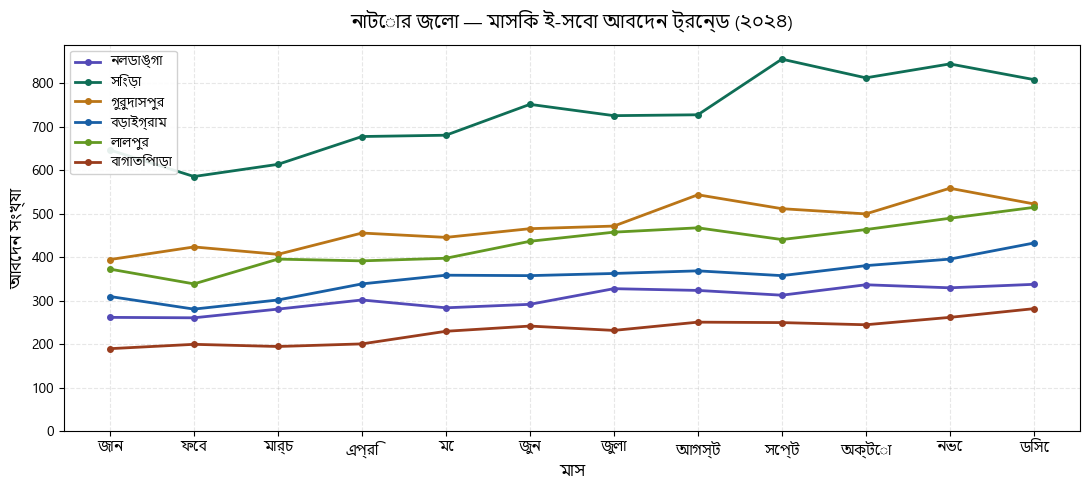

chart1_trend.png সেভ হয়েছে


In [16]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = ['#534AB7','#0F6E56','#BA7517','#185FA5','#639922','#993C1D']
for i, upazila in enumerate(df.columns):
    ax.plot(df.index, df[upazila], marker='o', markersize=4,
            linewidth=2, color=colors[i], label=upazila)

ax.set_title('নাটোর জেলা — মাসিক ই-সেবা আবেদন ট্রেন্ড (২০২৪)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('মাস', fontsize=11)
ax.set_ylabel('আবেদন সংখ্যা', fontsize=11)
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('chart1_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart1_trend.png সেভ হয়েছে")

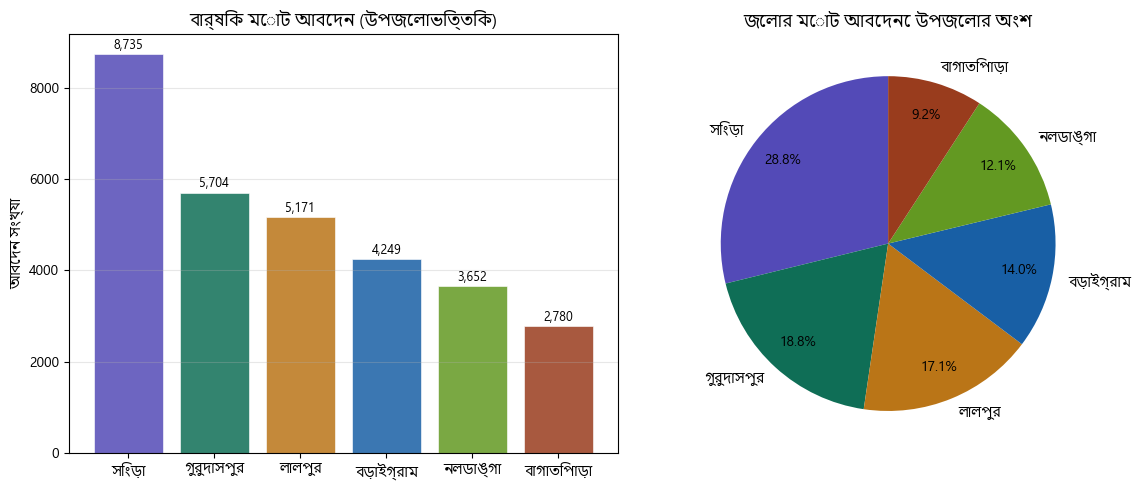

In [17]:
varshik_mot = df.sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# বাঁ দিক: মোট আবেদন
bars = axes[0].bar(varshik_mot.index, varshik_mot.values,
                   color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].set_title('বার্ষিক মোট আবেদন (উপজেলাভিত্তিক)', fontweight='bold')
axes[0].set_ylabel('আবেদন সংখ্যা')
axes[0].grid(True, axis='y', alpha=0.3)

# প্রতিটি bar-এর উপর মান লেখা
for bar, val in zip(bars, varshik_mot.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# ডান দিক: শতকরা ভাগ (Pie Chart)
axes[1].pie(varshik_mot.values, labels=varshik_mot.index,
            colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.8)
axes[1].set_title('জেলার মোট আবেদনে উপজেলার অংশ', fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_18308\3691165048.py:71: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_18308\3691165048.py:71: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_18308\3691165048.py:71: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_18308\3691165048.py:71: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_18308\3691165048.py:71: UserWarning: Glyph 2434 (\N{BENGALI SIGN ANUSVARA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_18308\3691165048.py:71: UserWarning: Glyph 2454 (\N{BENGALI LETTER KHA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\L

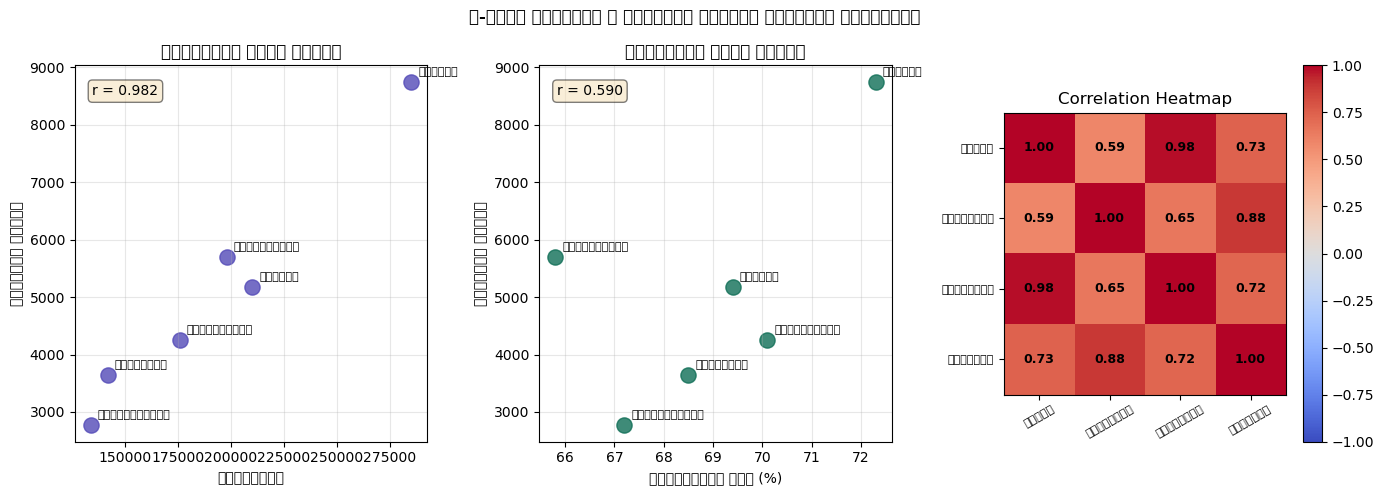

In [4]:
# সাক্ষরতা ও আবেদনের মধ্যে correlation
upazila_info = pd.DataFrame({
    'উপজেলা': list(base.keys()),
    'বার্ষিক_আবেদন': [df[u].sum() for u in base.keys()],
    'সাক্ষরতা': [68.5, 72.3, 65.8, 70.1, 69.4, 67.2],
    'জনসংখ্যা': [142000, 285000, 198000, 176000, 210000, 134000],
    'বিদ্যুৎ': [88.2, 92.5, 85.6, 89.3, 87.1, 83.4]
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('ই-সেবা ব্যবহার ও উন্নয়ন সূচকের সম্পর্ক বিশ্লেষণ',
             fontsize=12, fontweight='bold')

# Scatter 1: জনসংখ্যা বনাম আবেদন
axes[0].scatter(upazila_info['জনসংখ্যা'],
                upazila_info['বার্ষিক_আবেদন'],
                color='#534AB7', s=120, alpha=0.8)
for _, row in upazila_info.iterrows():
    axes[0].annotate(row['উপজেলা'],
                     (row['জনসংখ্যা'], row['বার্ষিক_আবেদন']),
                     textcoords='offset points', xytext=(5,5), fontsize=8)
axes[0].set_xlabel('জনসংখ্যা')
axes[0].set_ylabel('বার্ষিক আবেদন')
axes[0].set_title('জনসংখ্যা বনাম আবেদন')
axes[0].grid(True, alpha=0.3)

# Correlation মান দেখানো
r = np.corrcoef(upazila_info['জনসংখ্যা'],
                upazila_info['বার্ষিক_আবেদন'])[0,1]
axes[0].text(0.05, 0.95, f'r = {r:.3f}',
             transform=axes[0].transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Scatter 2: সাক্ষরতা বনাম আবেদন
axes[1].scatter(upazila_info['সাক্ষরতা'],
                upazila_info['বার্ষিক_আবেদন'],
                color='#0F6E56', s=120, alpha=0.8)
for _, row in upazila_info.iterrows():
    axes[1].annotate(row['উপজেলা'],
                     (row['সাক্ষরতা'], row['বার্ষিক_আবেদন']),
                     textcoords='offset points', xytext=(5,5), fontsize=8)
axes[1].set_xlabel('সাক্ষরতার হার (%)')
axes[1].set_ylabel('বার্ষিক আবেদন')
axes[1].set_title('সাক্ষরতা বনাম আবেদন')
axes[1].grid(True, alpha=0.3)
r2 = np.corrcoef(upazila_info['সাক্ষরতা'],
                 upazila_info['বার্ষিক_আবেদন'])[0,1]
axes[1].text(0.05, 0.95, f'r = {r2:.3f}',
             transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Correlation Heatmap
numeric_cols = ['বার্ষিক_আবেদন','সাক্ষরতা','জনসংখ্যা','বিদ্যুৎ']
corr_matrix = upazila_info[numeric_cols].corr()
im = axes[2].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[2].set_xticks(range(len(numeric_cols)))
axes[2].set_xticklabels(['আবেদন','সাক্ষরতা','জনসংখ্যা','বিদ্যুৎ'],
                         fontsize=8, rotation=30)
axes[2].set_yticks(range(len(numeric_cols)))
axes[2].set_yticklabels(['আবেদন','সাক্ষরতা','জনসংখ্যা','বিদ্যুৎ'],
                         fontsize=8)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        axes[2].text(j, i, f'{corr_matrix.iloc[i,j]:.2f}',
                     ha='center', va='center', fontsize=9, fontweight='bold')
axes[2].set_title('Correlation Heatmap')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('chart3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print("=" * 50)
print("  নাটোর জেলা ই-সেবা বার্ষিক পরিসংখ্যান রিপোর্ট")
print("=" * 50)

for upazila in df.columns:
    d = df[upazila]
    print(f"\n{upazila}:")
    print(f"  গড় মাসিক আবেদন : {d.mean():.0f}")
    print(f"  সর্বোচ্চ মাস    : {d.idxmax()} ({d.max()})")
    print(f"  সর্বনিম্ন মাস   : {d.idxmin()} ({d.min()})")
    print(f"  বার্ষিক প্রবৃদ্ধি: {((d.iloc[-1]-d.iloc[0])/d.iloc[0]*100):.1f}%")

print("\n" + "=" * 50)
print(f"জেলা মোট বার্ষিক আবেদন: {df.values.sum():,}")
print(f"সর্বোচ্চ আবেদনকারী  : {df.sum().idxmax()}")
print(f"সর্বনিম্ন আবেদনকারী : {df.sum().idxmin()}")

  নাটোর জেলা ই-সেবা বার্ষিক পরিসংখ্যান রিপোর্ট

নলডাঙ্গা:
  গড় মাসিক আবেদন : 304
  সর্বোচ্চ মাস    : ডিসে (338)
  সর্বনিম্ন মাস   : ফেব (261)
  বার্ষিক প্রবৃদ্ধি: 29.0%

সিংড়া:
  গড় মাসিক আবেদন : 728
  সর্বোচ্চ মাস    : সেপ্ট (856)
  সর্বনিম্ন মাস   : ফেব (586)
  বার্ষিক প্রবৃদ্ধি: 25.0%

গুরুদাসপুর:
  গড় মাসিক আবেদন : 475
  সর্বোচ্চ মাস    : নভে (559)
  সর্বনিম্ন মাস   : জান (395)
  বার্ষিক প্রবৃদ্ধি: 32.4%

বড়াইগ্রাম:
  গড় মাসিক আবেদন : 354
  সর্বোচ্চ মাস    : ডিসে (433)
  সর্বনিম্ন মাস   : ফেব (281)
  বার্ষিক প্রবৃদ্ধি: 39.7%

লালপুর:
  গড় মাসিক আবেদন : 431
  সর্বোচ্চ মাস    : ডিসে (515)
  সর্বনিম্ন মাস   : ফেব (339)
  বার্ষিক প্রবৃদ্ধি: 38.1%

বাগাতিপাড়া:
  গড় মাসিক আবেদন : 232
  সর্বোচ্চ মাস    : ডিসে (282)
  সর্বনিম্ন মাস   : জান (190)
  বার্ষিক প্রবৃদ্ধি: 48.4%

জেলা মোট বার্ষিক আবেদন: 30,291
সর্বোচ্চ আবেদনকারী  : সিংড়া
সর্বনিম্ন আবেদনকারী : বাগাতিপাড়া
